# Clean drifter data

Six surface drifters (IDs 298--303) were deployed in the Kiel Bight in
April 2023. The raw GPS tracks contain several non-science phases that
need to be removed before the trajectories can be used as initial
conditions or validation data:

- **Pre-deployment**: drifters sitting on a dock or boat, barely moving.
- **Deployment jump**: a sudden ~10 km jump when the drifters are
  carried out and released into the water.
- **Beaching**: drifters wash ashore on Danish islands; position becomes
  stationary.
- **Post-beaching**: trash trucks, facility depots, etc. Impossibly fast
  jumps.

This notebook flags each record by phase and extracts the clean science
phase for each drifter.

## Imports

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

## Parameters

In [ ]:
raw_csv = "data/drifters_raw.csv"
out_csv = "data/drifters_clean.csv"

# Baltic bounding box
lat_min, lat_max = 53.5, 56.0
lon_min, lon_max = 9.0, 13.0

# Minimum records per drifter to keep
min_records = 10

# Distance conversion: metres per degree (good enough at ~54.5N)
m_per_deg = 111120.0

# Deployment location (Kiel dock area)
deploy_lat, deploy_lon = 54.33, 10.15

# Speed and distance thresholds
deployment_radius_m = 2000.0  # within 2 km of dock = pre-deployment
beaching_speed = 0.005        # 1h rolling mean speed below this = beached (m/s)
impossible_speed = 2.0        # faster than any Baltic current (m/s)

## Load raw data

Parse dates, filter to Baltic region, drop drifters with too few records,
and deduplicate.

In [3]:
df = pd.read_csv(raw_csv, parse_dates=["date_UTC"])
df = df.sort_values(["D_number", "date_UTC"]).reset_index(drop=True)

# Filter to Baltic bounding box
df = df[
    (df["Latitude"] > lat_min) & (df["Latitude"] < lat_max)
    & (df["Longitude"] > lon_min) & (df["Longitude"] < lon_max)
]

# Deduplicate
df = df.drop_duplicates(subset=["D_number", "date_UTC"])

# Drop drifters with too few records
counts = df.groupby("D_number").size()
keep = counts[counts >= min_records].index
df = df[df["D_number"].isin(keep)].reset_index(drop=True)

print(f"{len(df)} records, {df['D_number'].nunique()} drifters")
print(f"Drifter IDs: {sorted(df['D_number'].unique())}")
print(f"Date range: {df['date_UTC'].min()} to {df['date_UTC'].max()}")

12496 records, 6 drifters
Drifter IDs: [np.int64(298), np.int64(299), np.int64(300), np.int64(301), np.int64(302), np.int64(303)]
Date range: 2023-04-20 10:04:49 to 2023-05-09 13:56:01


## Compute speed between consecutive points

For each drifter, compute the time step, displacement, and speed between
consecutive GPS fixes. We use a flat-Earth approximation with
1852 * 60 m/deg, which is adequate at this latitude.

In [4]:
def compute_speed(group):
    """Compute speed (m/s) between consecutive points for one drifter."""
    dt = group["date_UTC"].diff().dt.total_seconds()
    dlat = group["Latitude"].diff() * m_per_deg
    dlon = group["Longitude"].diff() * m_per_deg * np.cos(np.deg2rad(group["Latitude"]))
    dist = np.sqrt(dlat**2 + dlon**2)
    speed = dist / dt
    return pd.DataFrame({"dt_s": dt, "dist_m": dist, "speed_mps": speed}, index=group.index)

speed_cols = df.groupby("D_number", group_keys=False).apply(
    compute_speed, include_groups=False,
)
df = df.join(speed_cols)

df[["D_number", "date_UTC", "Latitude", "Longitude", "speed_mps"]].head(10)

,D_number,date_UTC,Latitude,Longitude,speed_mps
0,298,2023-04-20 10:04:49,54.32977,10.14909,NaN
1,298,2023-04-20 10:09:52,54.32967,10.14905,0.037658
2,298,2023-04-20 10:14:50,54.32969,10.14911,0.015027
3,298,2023-04-20 10:19:47,54.32991,10.14860,0.138402
4,298,2023-04-20 10:24:52,54.32973,10.14894,0.097561
5,298,2023-04-20 10:29:54,54.32981,10.14890,0.030661
6,298,2023-04-20 10:34:51,54.32964,10.14907,0.073628
7,298,2023-04-20 10:39:50,54.32958,10.14894,0.035929
8,298,2023-04-21 20:01:45,54.33014,10.14781,0.000800
9,298,2023-04-21 21:36:06,54.32989,10.14770,0.005066


## Phase detection

For each drifter, we walk through the timeline and assign phases:

1. **Pre-deployment**: records within 2 km of the Kiel dock location at
   the start of the track. This catches both the initial GPS fixes on
   the dock and any low-speed period before the drifters are carried out.
2. **Deployment jump**: the first record that leaves the deployment radius.
3. **Science**: normal drifting after leaving the dock area.
4. **Impossible speed**: any record with speed > 2 m/s (human handling).
5. **Beached**: 1h rolling mean speed drops below the beaching threshold.
6. **Post-beaching**: everything after the first beaching event.

In [5]:
def dist_from_dock(lat, lon):
    """Distance in metres from the deployment dock."""
    dlat = (lat - deploy_lat) * m_per_deg
    dlon = (lon - deploy_lon) * m_per_deg * np.cos(np.deg2rad(lat))
    return np.sqrt(dlat**2 + dlon**2)


def classify_phases(group):
    """Assign a phase label to each record of a single drifter."""
    g = group.sort_values("date_UTC").copy()
    n = len(g)
    phase = pd.Series("science", index=g.index)
    speed = g["speed_mps"].fillna(0).values
    dock_dist = dist_from_dock(g["Latitude"].values, g["Longitude"].values)

    # --- 1. Pre-deployment: initial records near the dock ---
    end_predeploy = -1
    for i in range(n):
        if dock_dist[i] < deployment_radius_m:
            end_predeploy = i
        else:
            break

    if end_predeploy >= 0:
        phase.iloc[: end_predeploy + 1] = "pre_deployment"

    # --- 2. Deployment jump: first record outside the dock radius ---
    science_start = end_predeploy + 1
    if science_start < n:
        phase.iloc[science_start] = "deployment_jump"
        science_start += 1

    # --- 3. Rolling-mean speed for beaching detection ---
    g_indexed = g.set_index("date_UTC")
    rolling_speed = g_indexed["speed_mps"].rolling("1h", min_periods=1).mean()
    rolling_speed = rolling_speed.values

    # --- 4. Impossible speed ---
    impossible = speed > impossible_speed

    # --- 5. Beaching: rolling mean speed below threshold ---
    beached = rolling_speed < beaching_speed

    # --- 6. Walk forward from after the deployment jump ---
    first_beach_idx = None

    for i in range(science_start, n):
        if impossible[i]:
            phase.iloc[i] = "impossible_speed"
        elif beached[i]:
            if first_beach_idx is None:
                first_beach_idx = i
            phase.iloc[i] = "beached"

    # --- 7. Everything after first beaching is post-beaching ---
    if first_beach_idx is not None:
        for i in range(first_beach_idx, n):
            if phase.iloc[i] == "science":
                phase.iloc[i] = "post_beaching"

    return phase


df["phase"] = df.groupby("D_number", group_keys=False).apply(
    lambda g: classify_phases(g), include_groups=False,
)

df.groupby(["D_number", "phase"]).size().unstack(fill_value=0)

phase,beached,deployment_jump,impossible_speed,post_beaching,pre_deployment,science
D_number,,,,,,
298,58,1,4,150,19,1888
299,333,1,15,1058,35,983
300,153,1,3,1015,33,827
301,1,1,48,11,29,1070
302,0,1,22,0,34,2266
303,11,1,21,396,24,1983


## Extract science phase

Keep only the records flagged as "science". These are the clean drifting
trajectories: after the deployment jump, before first beaching, with
impossible-speed records removed.

In [6]:
df_science = df[df["phase"] == "science"].copy()

for d_num, grp in df_science.groupby("D_number"):
    duration = grp["date_UTC"].max() - grp["date_UTC"].min()
    print(f"Drifter {d_num}: {len(grp)} records, {duration}")

Drifter 298: 1888 records, 10 days 12:57:57
Drifter 299: 983 records, 6 days 09:00:57
Drifter 300: 827 records, 6 days 05:10:43
Drifter 301: 1070 records, 10 days 11:34:24
Drifter 302: 2266 records, 12 days 14:32:46
Drifter 303: 1983 records, 12 days 12:46:59


## Map: trajectories colored by phase

All six drifters plotted with their full trajectories. Color indicates
the detected phase. The science phase should form clean, continuous
tracks from the Kiel Bight northeastward.

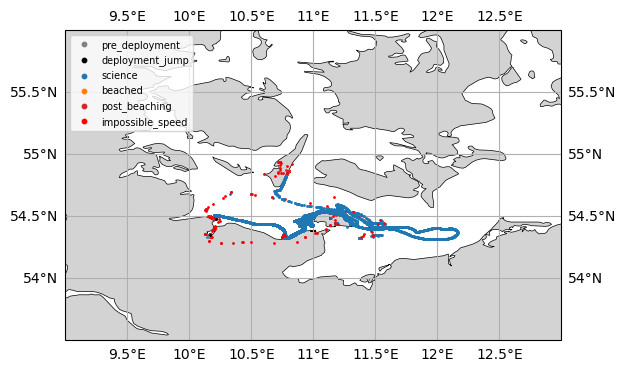

In [7]:
phase_colors = {
    "pre_deployment": "gray",
    "deployment_jump": "black",
    "science": "C0",
    "beached": "C1",
    "post_beaching": "C3",
    "impossible_speed": "red",
}

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(subplot_kw={"projection": proj})

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax.add_feature(cfeature.NaturalEarthFeature(
    "physical", "land", "10m", facecolor="lightgray", edgecolor="k", linewidth=0.5,
))
ax.gridlines(draw_labels=True)

# Plot each drifter, colored by phase
for d_num, grp in df.groupby("D_number"):
    for phase_name, color in phase_colors.items():
        mask = grp["phase"] == phase_name
        if mask.any():
            sub = grp[mask]
            ax.scatter(
                sub["Longitude"], sub["Latitude"],
                s=1, c=color, transform=proj, zorder=2,
            )

# Legend entries (one per phase)
for phase_name, color in phase_colors.items():
    ax.scatter([], [], c=color, s=10, label=phase_name)

ax.legend(fontsize=7, loc="upper left")
plt.show()

## Timeline: phase per drifter

Horizontal bars showing when each drifter is in each phase. Useful for
checking that the phase transitions look reasonable.

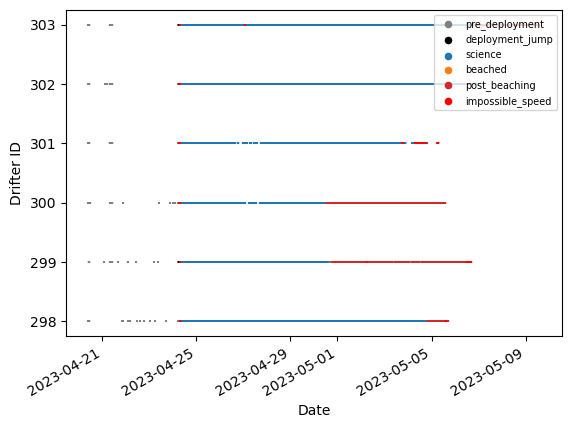

In [8]:
drifter_ids = sorted(df["D_number"].unique())

fig, ax = plt.subplots()

for i, d_num in enumerate(drifter_ids):
    grp = df[df["D_number"] == d_num].sort_values("date_UTC")
    for phase_name, color in phase_colors.items():
        mask = grp["phase"] == phase_name
        if mask.any():
            times = grp.loc[mask, "date_UTC"]
            ax.scatter(
                times, [i] * len(times),
                c=color, s=2, marker="|",
            )

ax.set_yticks(range(len(drifter_ids)))
ax.set_yticklabels(drifter_ids)
ax.set_ylabel("Drifter ID")
ax.set_xlabel("Date")

# Legend
for phase_name, color in phase_colors.items():
    ax.scatter([], [], c=color, s=20, label=phase_name)
ax.legend(fontsize=7, loc="upper right")

fig.autofmt_xdate()
plt.show()

## Note on military zone kinks

Some drifters show sudden direction changes near 10.75E longitude,
likely from navy patrol pickup and re-release. These events are subtle
and hard to distinguish automatically from normal current variability.
For now, records in this region remain flagged as "science". A future
pass could use heading-change analysis to flag them.

## Save clean trajectories

In [9]:
out_path = Path(out_csv)
out_path.parent.mkdir(parents=True, exist_ok=True)

df_science[["D_number", "date_UTC", "Latitude", "Longitude"]].to_csv(
    out_path, index=False,
)
print(f"Saved {len(df_science)} science-phase records to {out_path}")

Saved 9017 science-phase records to data/drifters_clean.csv
